# Amazon sales data analysis 4

## <span style="color: skyblue;"> Agenda </span>

- Multivariate Plots
    - Pair Plot
    - Heatmap
    - Stacked Plots

- Probability
  - Introduction to the Dataset & Business Context
  - Basic Probability Terminology & Concepts

# Multivariate Plots (Three or More Variables)

## Visualization Goal: Pair Plot
A pair plot visualizes pairwise relationships and distributions for multiple numerical variables. Let’s look at `rating`, `discounted_price`, and `actual_price`.

### Key Insights
* Quickly spot correlations.
* View distributions on the diagonal.

In [ ]:
!gdown 1WBGIqLNkmi_pWhC6i5tmfnTDARoPSaxd

Downloading...
From: https://drive.google.com/uc?id=1WBGIqLNkmi_pWhC6i5tmfnTDARoPSaxd
To: /content/amazon_data.csv
100% 6.04M/6.04M [00:00<00:00, 41.5MB/s]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('amazon_data.csv')

In [ ]:
df.loc[df['category']=="Car&Motorbike"]

,product_id,user_id,user_name,review_id,review_title,review_content,order_timestamp,product_name,category,discounted_price,...,rating_category,contains_durable,contains_sugar,contains_lead,product_qid,week_number,day_name,year,month,month_year
0,B0912WJ87V,"AG6W5HESRSDLBX3NCYOOUGFOWERA,AED4U5CF37HVSYPMD...","Arivazhagan,Ajit,swanand pandit,Venkatesh S.,S...","R3TOOFPX256D59,R1PR50BDQOEIIO,R392FI4QWXWOX5,R...","Liked it,User friendly and effective,Not as pe...","As of now its working fine, but don't expect m...",2023-10-15 16:03:56.065573772,Reffair AX30 [MAX] Portable Air Purifier for C...,Car&Motorbike,2339.0,...,Good,False,False,False,1672923598,41,Sunday,2023,10,October 2023


Numerical(continuous) - Histogram creates bins and counts the values.

cat - countplot - barplot - Mobile-count

Bar - category - count the values
Bar - category, count, mean, median, max

scatter - num num - Relationship between 2 num columns

line plot -Trend Date and Num(Trend)

box - cat vs num
box - num



histogram: bins and count,
bar: category and frequency, cat, median, cat and mean

Count: category and count of them.

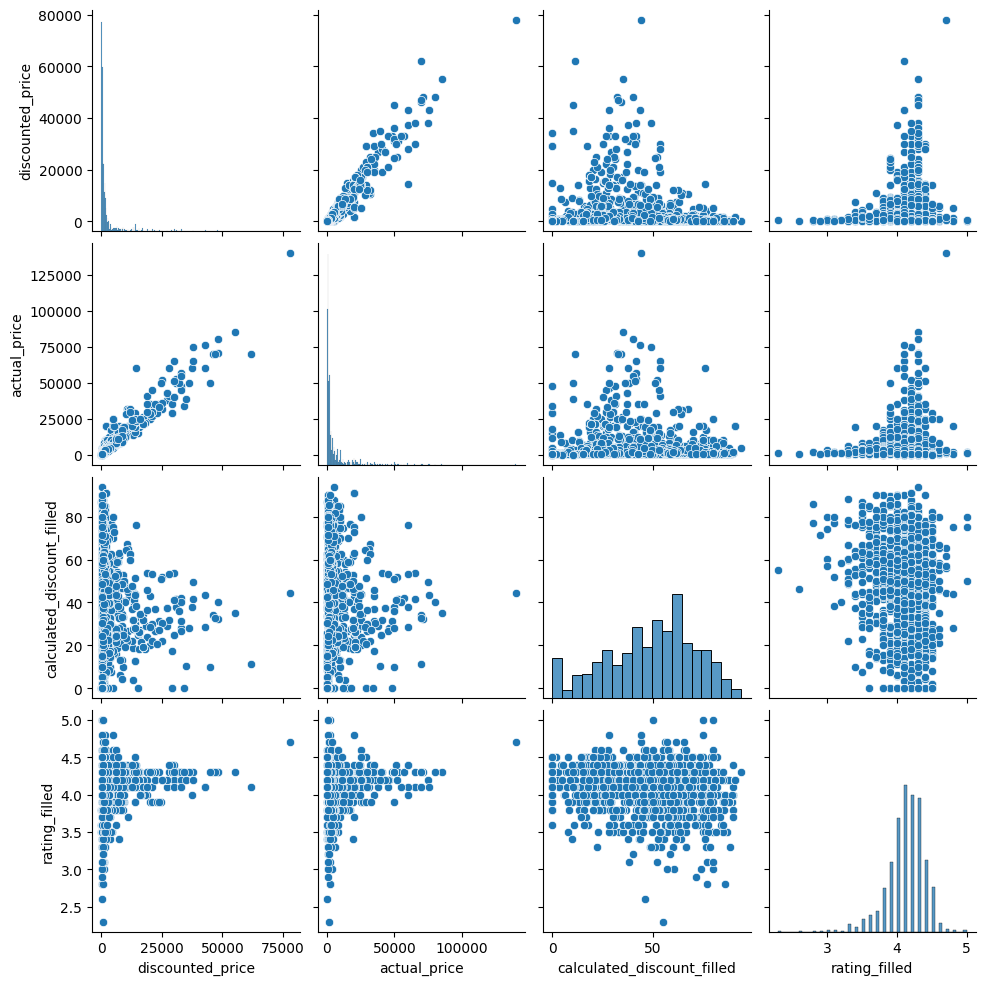

In [ ]:
sns.pairplot(data=df[['discounted_price', 'actual_price', 'calculated_discount_filled', 'rating_filled']])

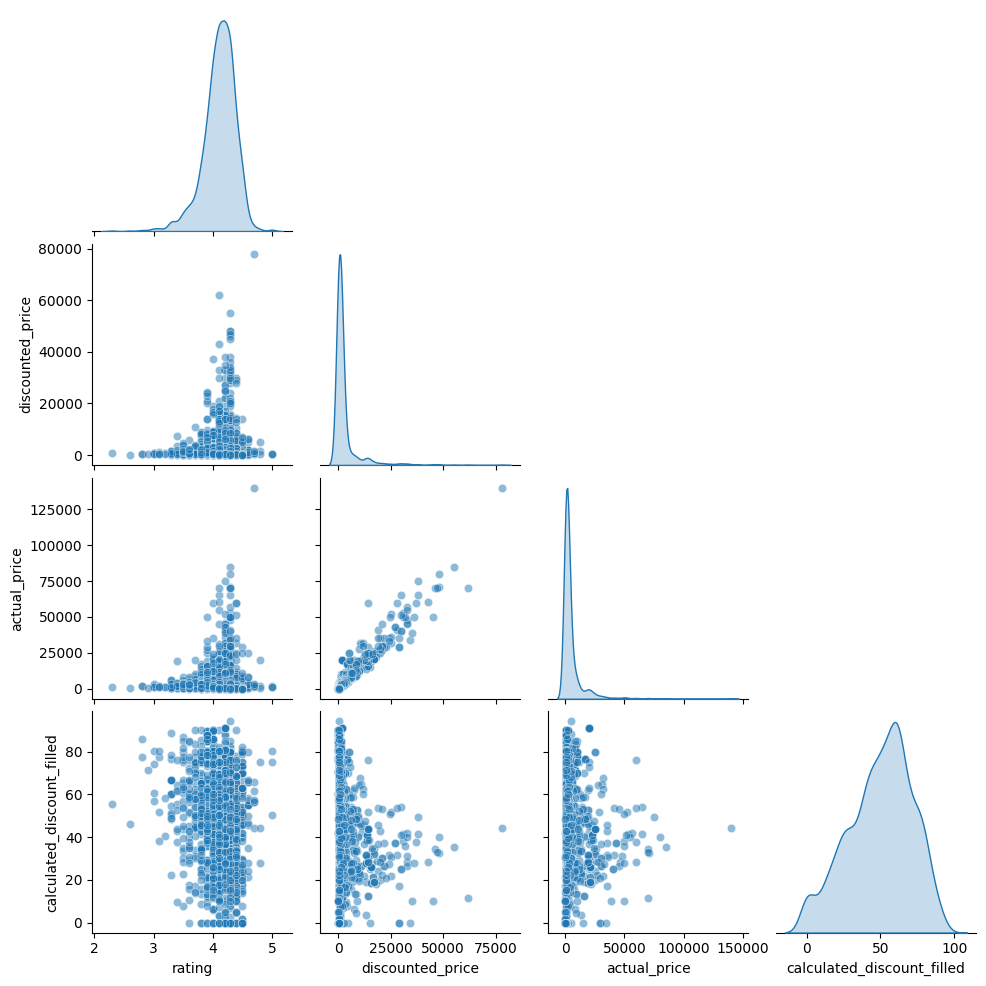

In [ ]:
sns.pairplot(df[['rating', 'discounted_price', 'actual_price', 'calculated_discount_filled']].dropna(),
             diag_kind='kde', corner=True, plot_kws={'alpha':0.5})
plt.show()

- The strong linear relationship between actual price and discounted price suggests that discounts are consistently applied as a proportion of the original price, with only minor variation across products.
- The scatter between `calculated_discount_filled` and `rating` continues to show no clear trend, indicating that discount levels are largely independent of product ratings.
- Mid-range products (₹10,000–₹30,000) show a higher concentration of discounts, reinforcing that this segment is more aggressively priced compared to both low-priced and high-end products.

### <span style=color:orange> Business Context:</span>

A pair plot provides Amazon with a comprehensive view of relationships among multiple numerical variables, helping inform pricing, discounting, and product strategy:

- Discount patterns: Observing that discounts are applied proportionally to actual prices confirms that pricing strategies are systematic rather than random.

- Pricing vs. ratings: Lack of a clear correlation between discounts and ratings suggests that higher discounts do not necessarily drive higher customer satisfaction, indicating other factors (like quality or brand) influence ratings more.

- Mid-range focus: Products in the mid-price range (₹10,000–₹30,000) receive higher discounts, highlighting a strategy to stimulate sales in this segment while maintaining margins on low- and high-end products.

- Strategic insights: Understanding these relationships helps in optimizing pricing, discounting strategies, and promotions, as well as identifying product segments where pricing adjustments could improve customer satisfaction and sales.

## Visualization Goal: Heatmap
A heatmap is great for correlation matrices. Let’s see how `rating`, `discounted_price`, `actual_price`, `rating_count`, etc., correlate.

### Key Insights
* Identify strong positive or negative correlations.
* Guides feature selection or further analysis.

In [ ]:
corr_cols = ['rating', 'discounted_price', 'actual_price', 'rating_count', 'calculated_discount']
corr_matrix = df[corr_cols].corr()
corr_matrix

,rating,discounted_price,actual_price,rating_count,calculated_discount
rating,1.000000,0.102599,0.107635,0.107167,-0.145956
discounted_price,0.102599,1.000000,0.961293,-0.028338,-0.251865
actual_price,0.107635,0.961293,1.000000,-0.037752,-0.129300
rating_count,0.107167,-0.028338,-0.037752,1.000000,0.014346
calculated_discount,-0.145956,-0.251865,-0.129300,0.014346,1.000000


<Axes: >

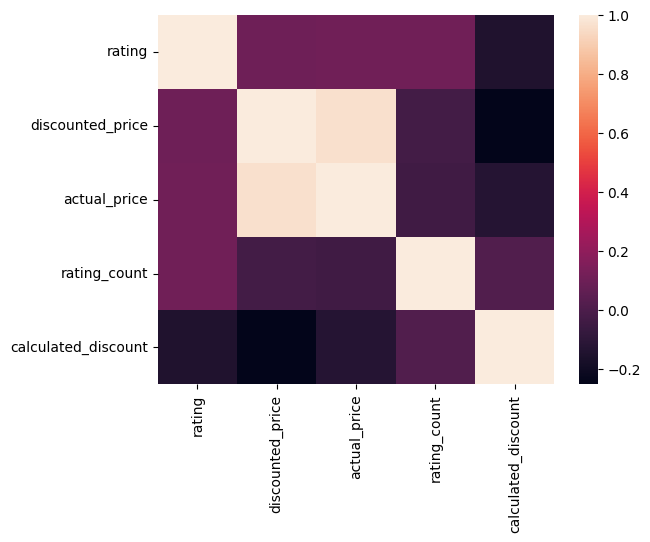

In [ ]:
sns.heatmap(corr_matrix)

<Axes: >

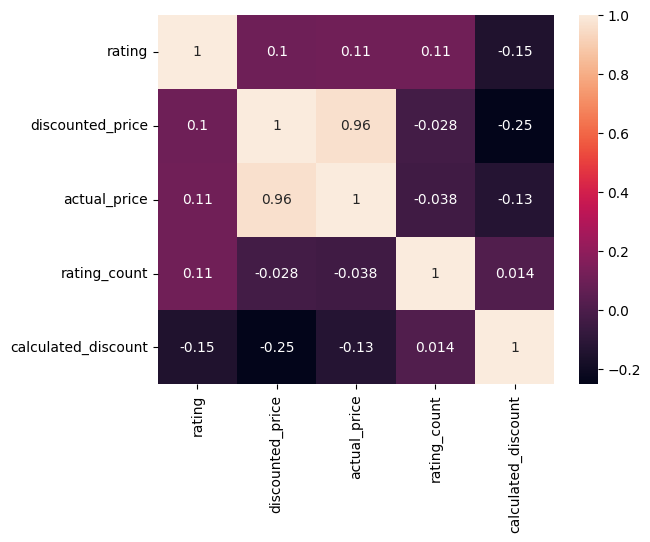

In [ ]:
sns.heatmap(corr_matrix,annot=True)

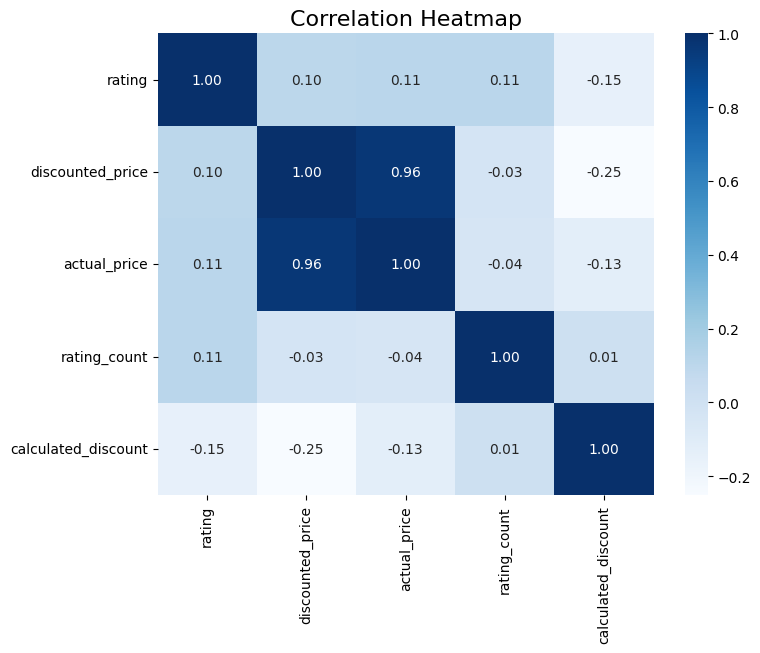

In [ ]:
corr_cols = ['rating', 'discounted_price', 'actual_price', 'rating_count', 'calculated_discount']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

# Styling Tip
# Format annotation to 2 decimal places
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues')

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

- again discounted prices are directly proportional to actual prices, meaning discounts are percentage-based rather than fixed amounts.
- Rating vs. Discounted Price (0.10) and Rating vs. Actual Price (0.11) show almost no correlation, meaning higher-priced products do not necessarily get better ratings.
- Since high discounts do not lead to better ratings, businesses should prioritize improving product quality and customer service rather than relying on heavy discounts.
- Since expensive products do not necessarily get higher ratings, consider adding value through better warranties, customer support, and post-purchase engagement to boost satisfaction.

<Axes: >

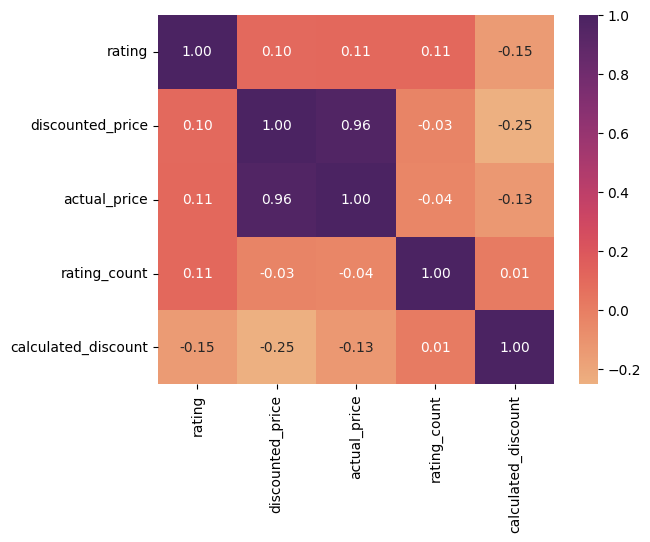

In [ ]:
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="flare")

In [ ]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

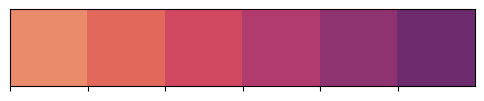

In [ ]:
sns.palplot(sns.color_palette("flare"))

### <span style=color:orange> Business Context:</span>

A correlation heatmap helps Amazon understand how numerical variables interact, providing insights into pricing strategies, customer satisfaction, and business priorities:

- Discount vs. actual price: The strong positive correlation confirms that discounts are applied as a percentage of the original price, indicating a consistent pricing strategy.

- Price vs. rating: Weak correlations between rating and discounted or actual price suggest that higher prices do not guarantee higher customer satisfaction, highlighting the importance of product quality and customer experience over pricing alone.

- Discount vs. rating: Minimal correlation indicates that offering higher discounts does not necessarily improve ratings, emphasizing that Amazon should focus on enhancing product features, warranties, and post-purchase support rather than relying solely on discounts to drive satisfaction.

- Strategic implications: These insights guide pricing policies, product development, and customer engagement strategies, ensuring that efforts to increase sales do not compromise long-term customer satisfaction.


## Subplots and hue
The `hue` parameter in **Seaborn** allows us to color the data points (or bars, lines, etc.) by another categorical variable, giving a quick comparison without creating separate subplots or separate figures.

**Example: Bar Plot with Hue**

Let’s say we want to compare the **average rating** by `rating_category` for products that **do or do not contain “durable”**. We'll use the `contains_durable` column as the `hue` parameter.

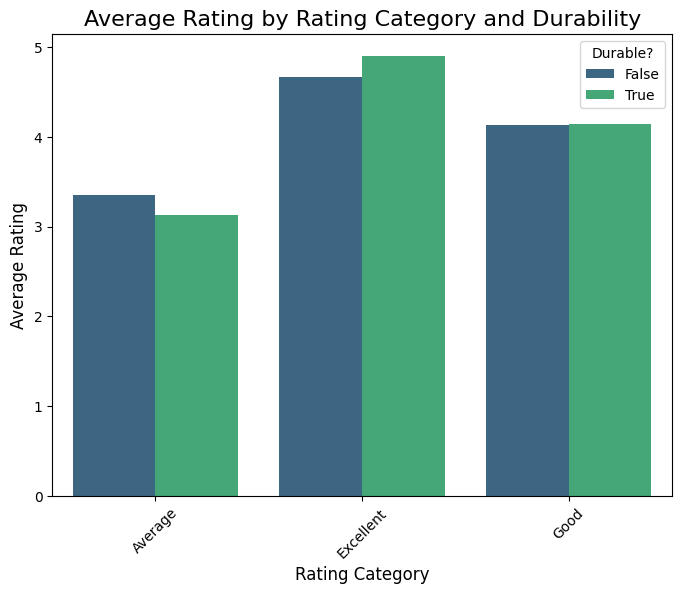

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Group by rating_category and contains_durable, then compute average rating
grouped_data = df.groupby(['rating_category', 'contains_durable'])['rating_filled'].mean().reset_index()

sns. barplot(
    data=grouped_data,
    x='rating_category',
    y='rating_filled',
    hue='contains_durable',
    palette='viridis'
)

# Styling Tip 💡
# Add a legend title and rotate x-axis labels
plt.legend(title='Durable?')
plt.xticks(rotation=45)
plt.title("Average Rating by Rating Category and Durability", fontsize=16)
plt.xlabel("Rating Category", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.show()

In [ ]:
grouped_data = df.groupby(['category','contains_durable'])['rating_filled'].mean().reset_index()
grouped_data

,category,contains_durable,rating_filled
0,Car&Motorbike,False,3.800000
1,Computers&Accessories,False,4.164679
2,Computers&Accessories,True,4.149000
3,Electronics,False,4.085605
4,Electronics,True,4.128571
5,Health&PersonalCare,False,4.000000
6,Home&Kitchen,False,4.059472
7,Home&Kitchen,True,3.941667
8,HomeImprovement,False,4.250000
9,MusicalInstruments,False,3.900000


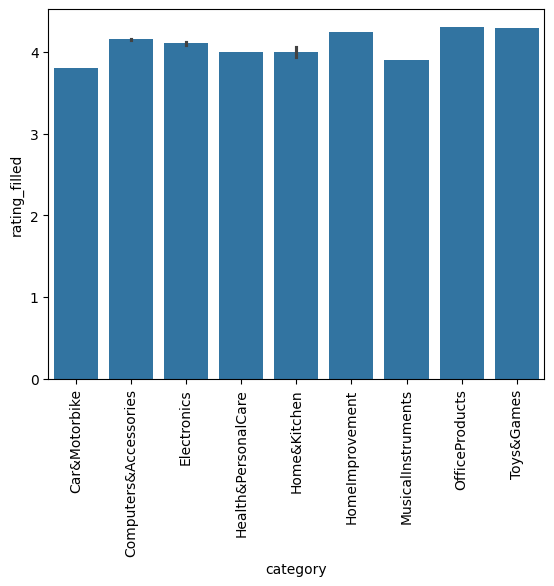

In [ ]:
sns.barplot(data=grouped_data, x='category', y='rating_filled')
plt.xticks(rotation=90)
plt.show()

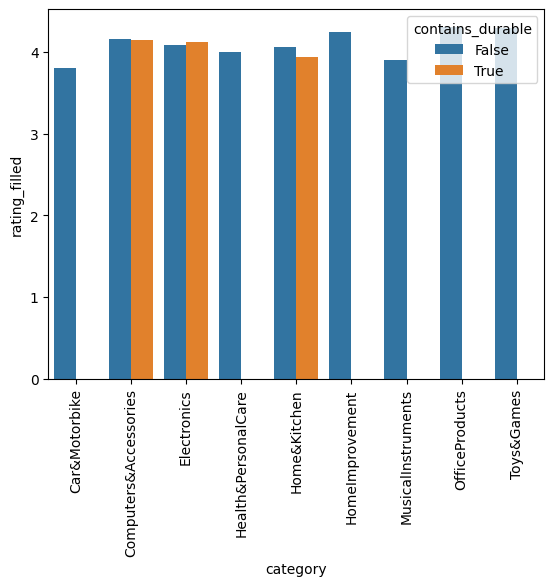

In [ ]:
sns.barplot(data=grouped_data, x='category', y='rating_filled', hue='contains_durable')
plt.xticks(rotation=90)
plt.show()

### <span style=color:orange> Business Context:</span>

Using the hue parameter allows Amazon to analyze multiple dimensions simultaneously, providing richer insights without creating separate charts:

- Durability impact: By coloring bars based on whether products are labeled as “durable,” we can see how durable products perform compared to non-durable ones within each rating category.

- Customer satisfaction insights: This helps identify product features that drive higher ratings, highlighting that durable products generally receive better feedback.

- Marketing and positioning: Insights from this visualization can inform marketing campaigns, product descriptions, and feature promotion, emphasizing durability to boost customer trust and sales.

- Operational strategy: Categories with low-rated non-durable products can be targeted for quality improvements, better materials, or supplier evaluation.

### Subplots with Different Hues

Sometimes, you may want multiple subplots side by side, each using a different hue variable. This can be useful if you have multiple categorical variables you want to highlight in separate views.

**Example:** Two Scatter Plots with Different Hues

* In the first subplot, we'll color by `rating_category`.
* In the second subplot, we’ll color by the `price_range` column (imagine it categorizes items as “Budget”, “Mid-range”, “Premium”, etc.).

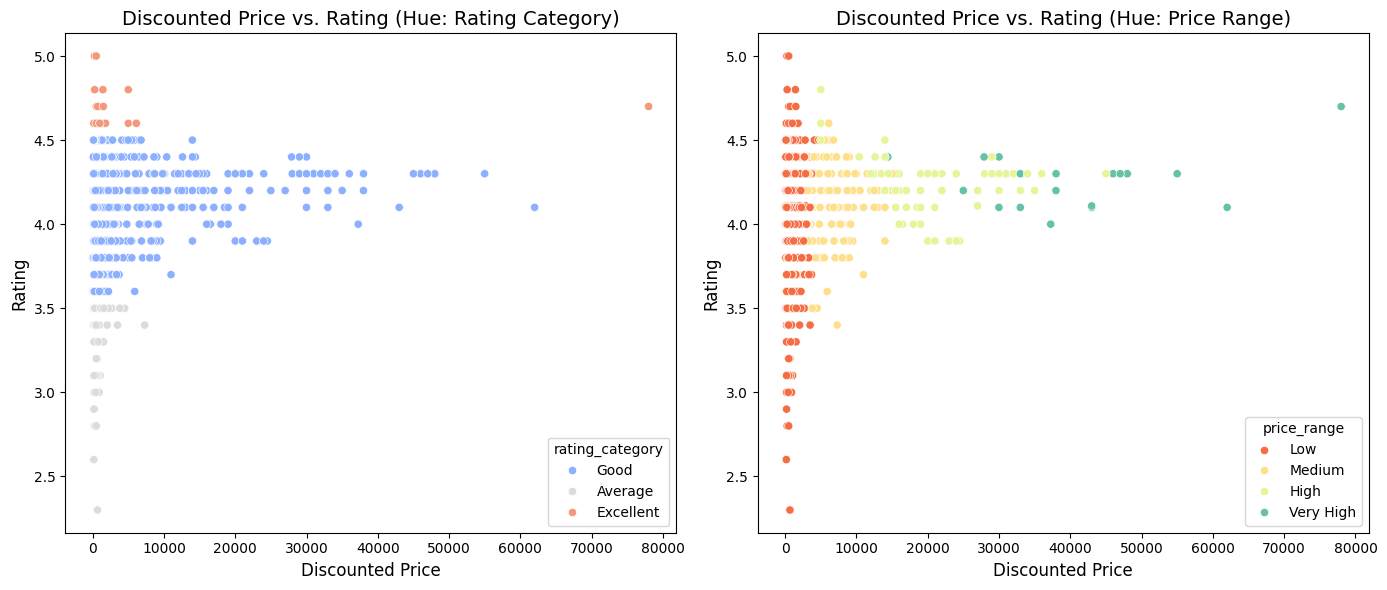

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Hue by 'rating_category.'
sns. scatterplot(
    data=df,
    x='discounted_price',
    y='rating_filled',
    hue='rating_category',
    ax=axes[0],
    palette='coolwarm'
)
axes[0].set_title("Discounted Price vs. Rating (Hue: Rating Category)", fontsize=14)
axes[0].set_xlabel("Discounted Price", fontsize=12)
axes[0].set_ylabel("Rating", fontsize=12)

# Subplot 2: Hue by 'price_range.'
sns. scatterplot(
    data=df,
    x='discounted_price',
    y='rating_filled',
    hue='price_range',  # Alternatively: 'actual_price', binned, or another categorical col
    ax=axes[1],
    palette='Spectral'
)
axes[1].set_title("Discounted Price vs. Rating (Hue: Price Range)", fontsize=14)
axes[1].set_xlabel("Discounted Price", fontsize=12)
axes[1].set_ylabel("Rating", fontsize=12)

plt.tight_layout()
plt.show()

- low-priced products have both high and low ratings, indicating inconsistent quality.
- should invest in quality assurance and ensure consistency in product descriptions and expectations.

In [ ]:
# Let's import monthly ratings
!gdown 1RZNjDjRrO-IeyOYN_Iu6CejlcUE8OIwr

Downloading...
From: https://drive.google.com/uc?id=1RZNjDjRrO-IeyOYN_Iu6CejlcUE8OIwr
To: /content/monthly_ratings.csv
100% 388/388 [00:00<00:00, 1.78MB/s]


In [ ]:
monthly_rating = pd.read_csv('monthly_ratings.csv')
monthly_rating

,month_year,rating_filled
0,January 2023,4.147400
1,February 2023,4.107155
2,March 2023,4.102384
3,April 2023,4.122943
4,May 2023,4.091247
5,June 2023,4.135645
6,July 2023,4.168809
7,August 2023,4.149130
8,September 2023,4.097056
9,October 2023,4.075679


/tmp/ipykernel_608/388824672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
/tmp/ipykernel_608/388824672.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
/tmp/ipykernel_608/388824672.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette


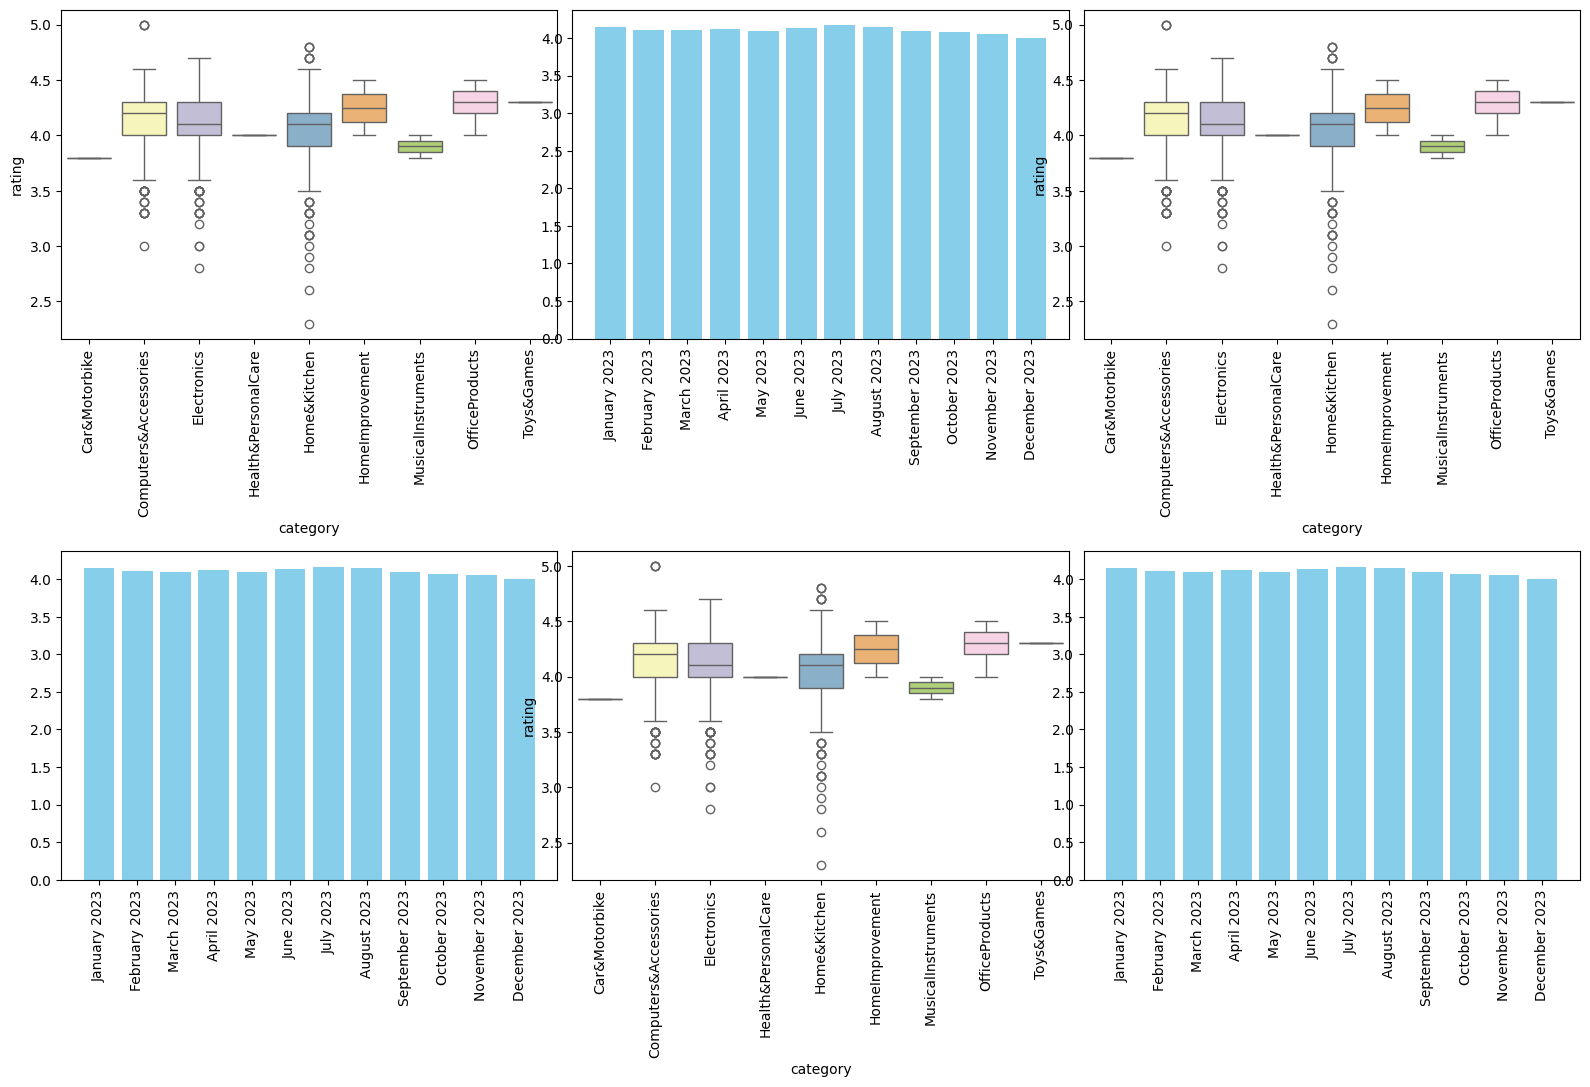

In [ ]:
plt.figure(figsize=(16,9))
plt.subplot(2,3,1)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)
plt.tight_layout()


plt.subplot(2,3,2)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)


plt.subplot(2,3,3)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(2,3,4)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)


plt.subplot(2,3,5)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(2,3,6)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)

plt.show()

/tmp/ipykernel_608/661198017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
/tmp/ipykernel_608/661198017.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
/tmp/ipykernel_608/661198017.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette


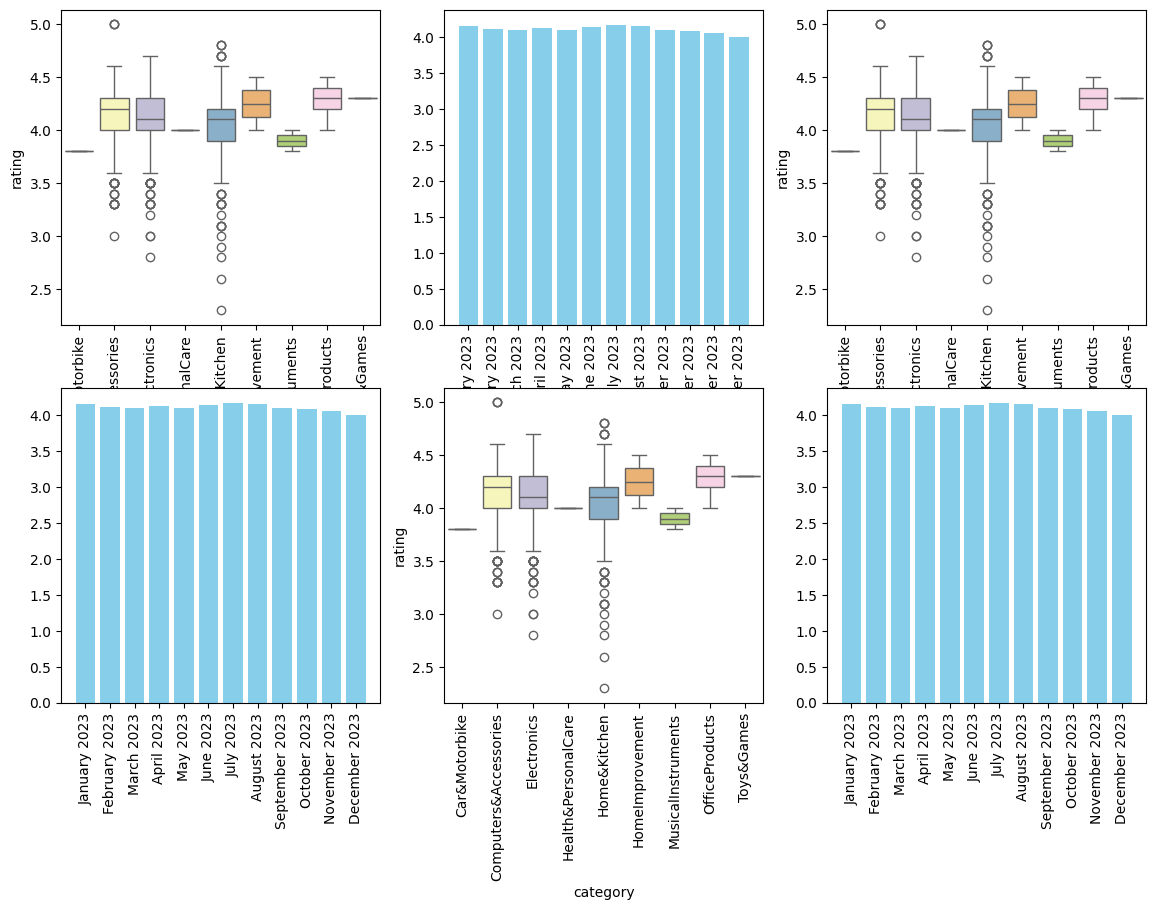

In [ ]:
plt.figure(figsize=(14,9))
plt.subplot(2,3,1)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)


plt.subplot(2,3,2)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)


plt.subplot(2,3,3)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(2,3,4)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)


plt.subplot(2,3,5)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(2,3,6)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)

plt.show()

/tmp/ipykernel_608/2212429525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
/tmp/ipykernel_608/2212429525.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette


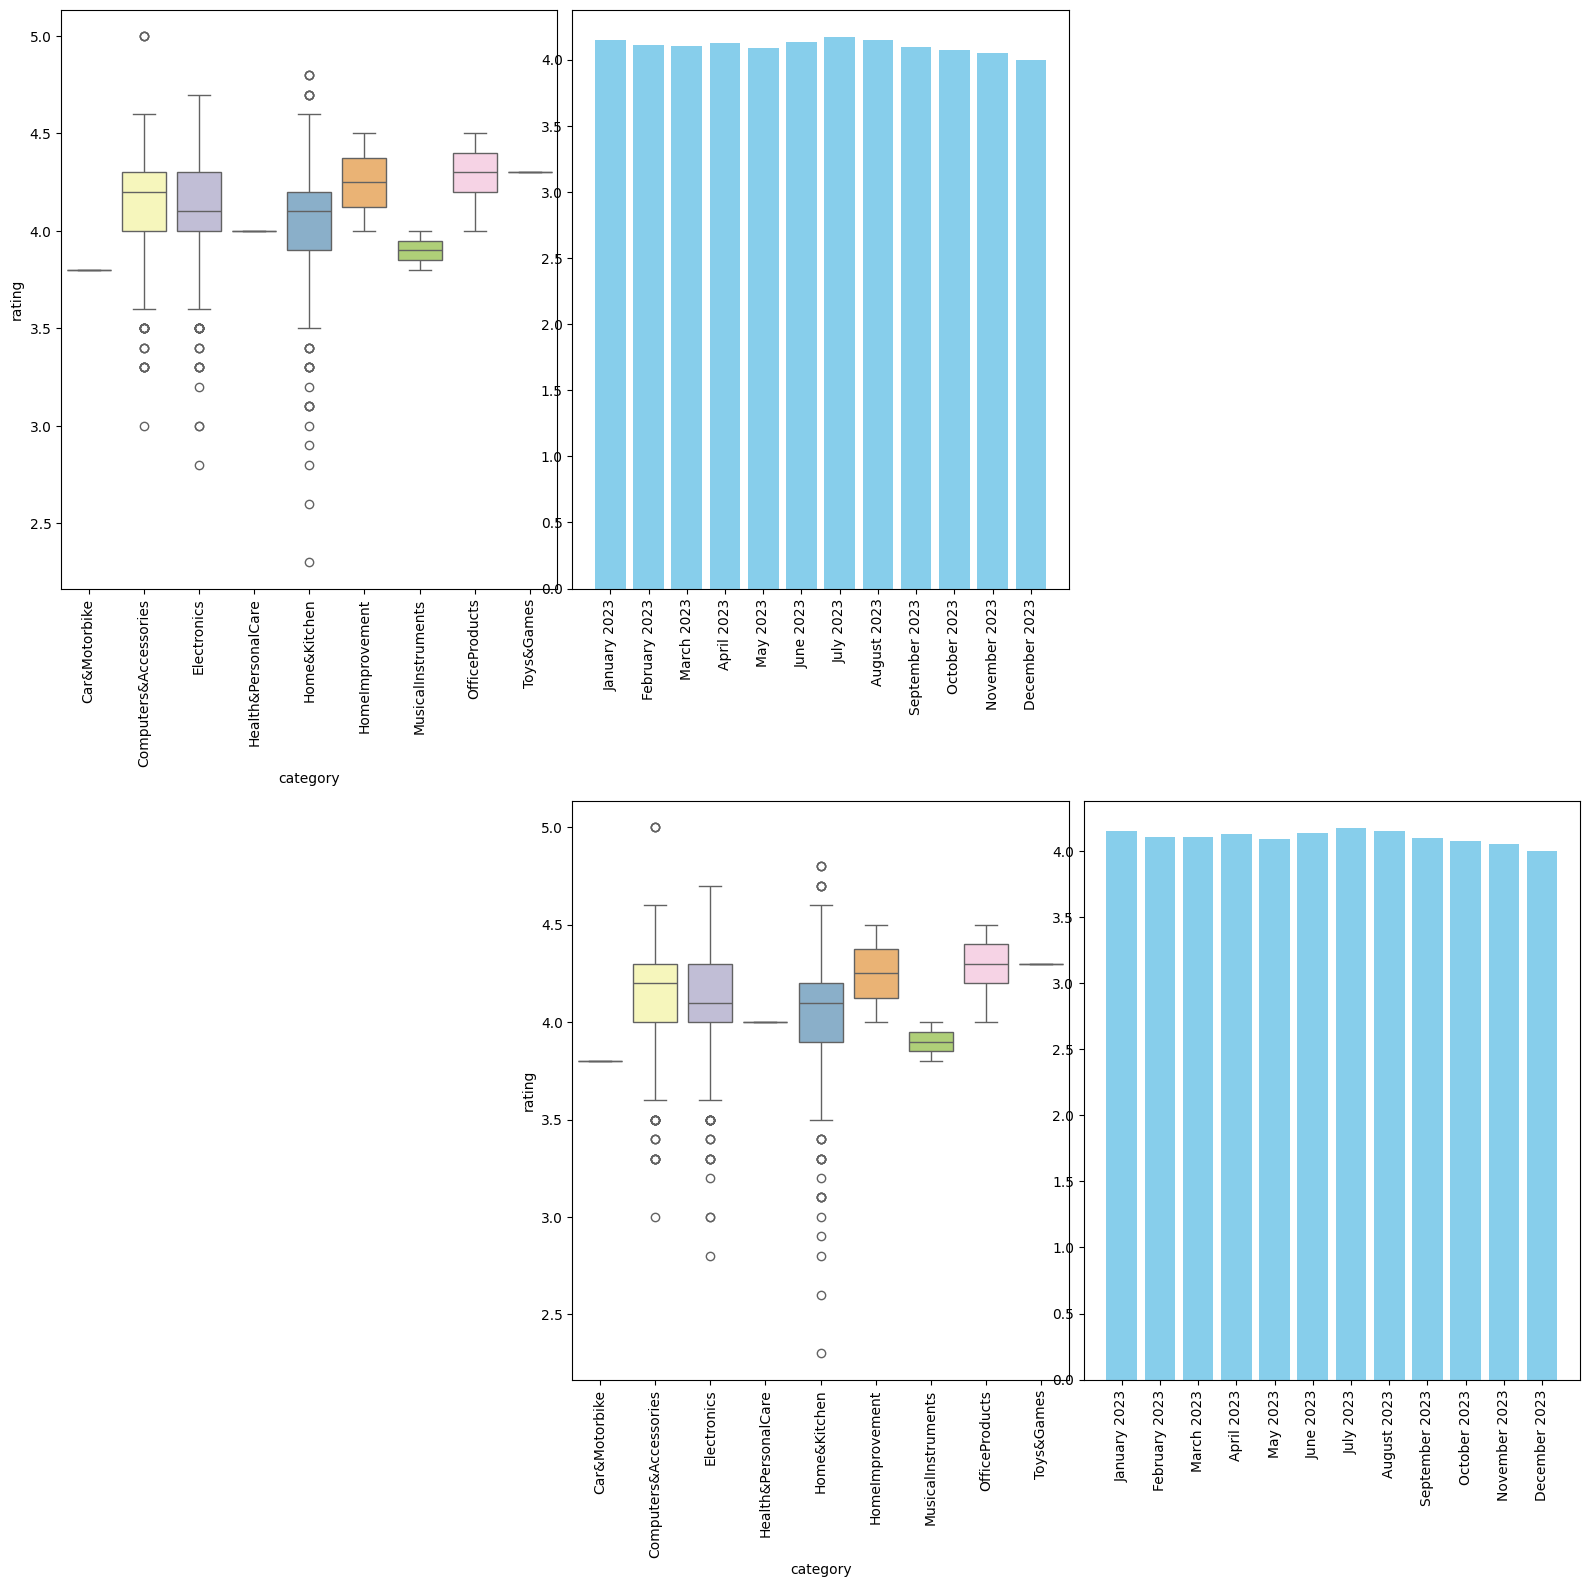

In [ ]:
plt.figure(figsize=(16,14))
plt.subplot(2,3,1)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)
plt.tight_layout()


plt.subplot(2,3,2)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)


plt.subplot(2,3,5)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(2,3,6)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)

plt.show()

/tmp/ipykernel_608/4046999453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette


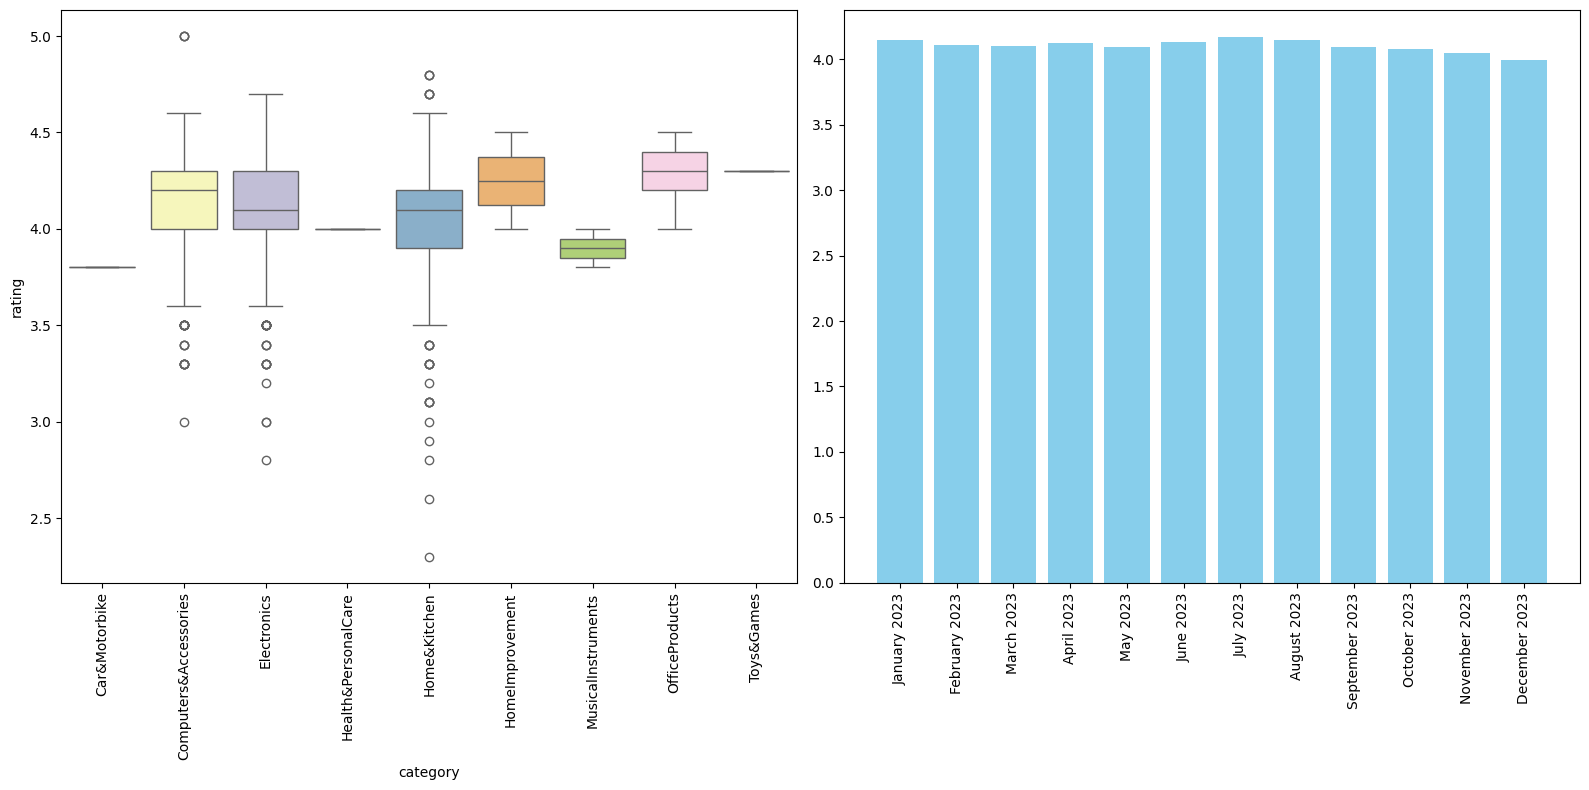

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='category', y='rating', palette='Set3') # Styling Tip palette
plt.xticks(rotation=90)

plt.subplot(1,2,2)
plt.bar(monthly_rating['month_year'], monthly_rating['rating_filled'], color='skyblue')
plt.xticks(rotation=90)
plt.tight_layout()

### <span style=color:orange> Business Context:</span>

Using multiple subplots with different hues allows Amazon to compare the same relationship across different categorical dimensions, providing deeper insights into product performance and pricing strategies:

- Rating category insights: Coloring by rating_category helps identify how products in different satisfaction tiers perform across price points, revealing clusters of low-rated or high-rated items.

- Price range insights: Coloring by price_range highlights whether budget, mid-range, or premium products achieve higher ratings, exposing potential quality or value inconsistencies.

- Operational implications: Observing that low-priced products have both high and low ratings signals the need for better quality control, accurate product descriptions, and expectation management.

- Strategic actions: These insights inform product sourcing, quality assurance, marketing messaging, and pricing strategies to enhance customer satisfaction and reduce returns or complaints.

## Stacked Plots
A stacked plot (most commonly a stacked bar plot) allows you to see parts of a whole for different categories on top of each other.

1 Stacked **Bar Plot** Let’s say we want to visualize how rating_category is distributed within each `price_range` category. This will show each price range on the x-axis and “stack” the segments of rating categories in each bar.

**Steps:**

* Compute counts of reviews (or any metric) grouped by price_range and rating_category.
* Unstack the grouped data so each rating_category becomes a separate column.
* Use Matplotlib (pandas plotting) with stacked=True.

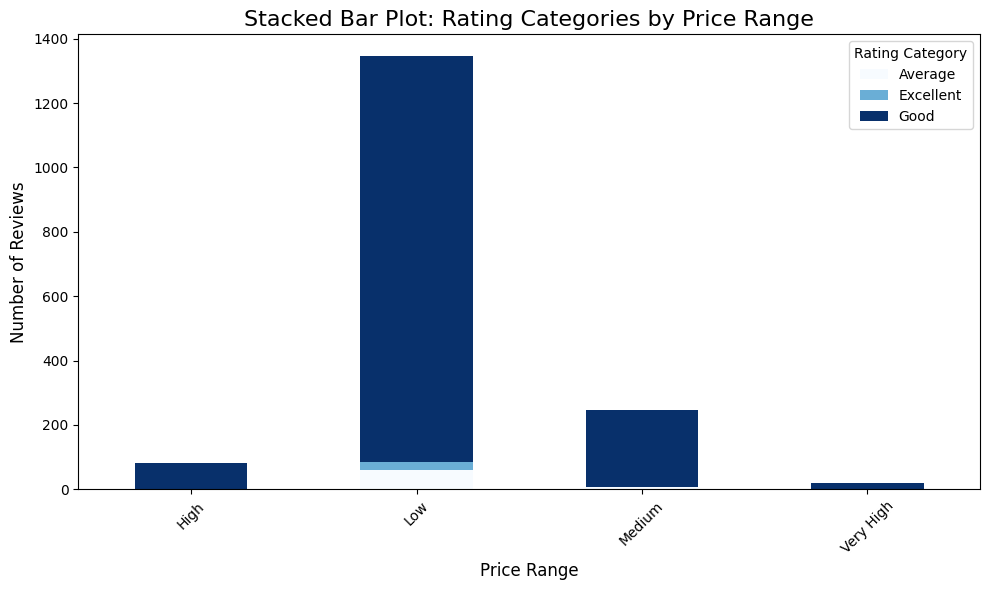

In [ ]:
# 1. Group by price_range and rating_category, and get counts
grouped_stack = df.groupby(['price_range', 'rating_category'])['review_id'].count().unstack()

# 2. Plot as a stacked bar
grouped_stack.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Blues'
)

# Styling Tip
plt.title("Stacked Bar Plot: Rating Categories by Price Range", fontsize=16)
plt.xlabel("Price Range", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.legend(title="Rating Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Encourage More Reviews for High & Very High-Priced Products
- identify patterns in negative reviews of low-priced products and address recurring complaints to reduce refund rates and improve trust.

<span style="background-color: red;color: White;">Note:</span> A stacked bar plot can become hard to read if there are many categories. In such cases, a grouped bar chart or a different type of visualization might be more suitable.

### <span style=color:orange> Business Context:</span>

A stacked bar plot showing the distribution of rating categories within each price range provides Amazon with insights into customer satisfaction patterns across different pricing segments:

- Review distribution: By visualizing how “Poor,” “Average,” and “Excellent” ratings stack within budget, mid-range, and premium products, Amazon can identify which price segments receive more negative or positive feedback.

- High-priced products: Encouraging reviews for high and very high-priced products can increase credibility and assist customers in making informed purchase decisions.

- Low-priced products: Identifying patterns of negative reviews in budget products highlights quality issues or recurring complaints, guiding product improvements, supplier evaluation, or description enhancements to reduce refunds and boost trust.

- Strategic decision-making: This visualization helps category managers, quality assurance teams, and marketing strategists to optimize product offerings, pricing strategies, and customer engagement efforts.
                                                          
## Conclusion

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/166/464/original/Screenshot_2024-12-27_103544.png?1763572840" width="900" />


Visualization is about **asking the right question** and **picking the right plot** for both your **data** and your **audience**. We’ve covered a range of plots—univariate, bivariate, and multivariate—and explored how to add extra dimensions via **hue**, **subplots**, and **stacked** techniques.

- **Focus on the story** you want to tell; each plot should highlight a key insight or pattern.  
- **Keep it simple**: avoid clutter, label axes clearly, and use color thoughtfully.  
- **Know your audience**: are they familiar with complex plots, or do they prefer simpler visualizations?  
- **Iterate**: no single plot is perfect; try multiple approaches to see what communicates insights best.

**Remember**: A plot is only as powerful as the **question** it helps answer. Combine clarity, audience awareness, and the right techniques to deliver compelling data stories.

<span style=background-color:red>**Instructor Note:**</span> Open this cheetsheet at the end of the lecture to answer questions, if you have time [link](https://drive.google.com/file/d/1EDV3aiBRzw8zgGD7i0wj3mmCWOt541P4/view)

# Question
Which of the following is NOT a correct interpretation during EDA?
# Choices
- [ ] A high standard deviation means values are more spread out.
- [ ] If mean ≠ median, the distribution might be skewed.
- [x] If correlation is 0, the variables are independent.
- [ ] Outliers can significantly affect the mean but less so the median.


Explanation: Correlation = 0 means no linear relationship, but variables can still be related nonlinearly.

# Syllabus Discussion

- We are all learning AIML and specifically Applied AI.
    -  Now we have one more term that is DSML, which consists of NumPy, Pandas, Matplotlib.
    - And then we have probability, distribution, hypothesis testing, and basically.
    - After all of this, we start with machine learning.

- But in Applied AI, things have changed. Here, after your NumPy, Pandas, and Matplotlib, we will have a refresher lecture on probability
    - And then ML, DL, Agent,
    - And once that part is done, we will have the Maths module in a detailed manner.

- <span style="color: violet;">But why did we move from the DSML module to Applied AI?</span>

- <span style="color: violet;">See, as a data scientist, have you seen any change in your current company? Like what they are asking for nowadays?</span>

<span style="background-color: red;color: White;">Student's answer:</span> GenAI, Agentic AI & Gen AI, Work experience with LLMS, Ml(Predictive modelling), Gen AI, MLOPS, langchain langgraph

- Yes, if you see every company is looking for GenAI, they are not asking much about ML, Probability, and all.
    - So, our complete agenda will be related to this.

Let's start with a very interesting module, **Probability**.

- You have a very well-known example of Probability that is Toss a coin and get a head or tail (Probability of head or tail is 1/2)

# Probability Use Cases

> **Why probability matters in ML:** Machine learning models often do not give final yes-or-no answers. Instead, they give probability-based outputs like:
> * There is a 70 percent chance this email is spam.
> * There is a 20 percent chance option B will happen.
> * There is a 10 percent chance option C will happen.
>
> The model chooses the most probable answer. That is why understanding probability is important before machine learning.

- <span style="color: violet;">**When Maggie was banned, did anyone know the reason?**</span>
    - Yes, there is lead present in Maggie, and the amount was greater than the threshold(approx 4.3ppm).
- <span style="color: violet;">But at that time Nestle had almost let's say 4cr packets in their factory. **Did the Govt. check every packet?**</span>
    - No, that's actually not possible for testing 4cr packets.
    - So, they chose random packets, did the testing, and reached a value of 4.3ppm.
    
There are several use cases of probability such as:

## <span style="color: skyblue;">Use Case 1</span>

- Imagine you have a coin and toss it 10 times.
    - The result comes as 6 times head and 4 times tail (H>T).
    - This is in a completely random manner.
    - From 10 samples, we cannot say that is this a unbiased coin.
- To get a biased coin, the heads and tails should be the same number of times.

- Now, Imagine if I toss the same coin for 10,000 times.
    - The result comes as 9000 times head and 1000 times tail (H>T).
    - We can clearly say it is a biased coin.
    - That's how probaility helps us to solve things.

## <span style="color: skyblue;">Use Case 2</span>
- When we type in mobile chat, `How are`...
    - We  may get 3 suggestions:
        - they
        - you
        - him
    - These suggestions changes based on the previous sentence we type.
    - It calculates the most probable word.

## <span style="color: skyblue;">Other Use Cases</span>
- On television, channels show probability of winning of each team during live cricket matches.
- In IRCTC app, we see seat allotment probability.
- Click-through ratio is analyzed in UI designs of websites like Amazon.

## <span style="color: skyblue;">Use Case: Spam Detection</span>

Email spam detection is also probability-based.

When an email arrives, the system estimates:
* Probability that the email is spam
* Probability that the email is not spam

If the spam probability is high, the email goes to the spam folder automatically.

This decision is based on patterns learned from historical emails — exactly what probability and machine learning do together.

So let's start with probability in a business context.

# Introduction to the Dataset & Business Context

### About the Dataset and Business Case

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/166/997/original/Screenshot_2025-11-21_161617.png?1763721986" width="900" />

**Dataset:** Sachin Tendulkar ODI Cricket Career 🏏
We are analyzing a dataset containing the ODI (One Day International) cricket stats of Sachin Tendulkar, one of the greatest cricketers of all time. The dataset provides detailed performance metrics across 360 matches of his illustrious career. By studying this data, we can explore and gain insights into:
* Performance Patterns: Runs, strike rate, centuries, boundaries, and other key performance indicators.
* Match Outcomes: The relationship between Sachin's performances and the overall outcomes of matches (win or loss).
* Opposition & Venue Analysis: How performance varies against different opponents and at specific grounds.

**Key Business Objectives:**

* Understanding Winning Patterns: Explore how Sachin’s performance influenced match results.
* Performance Insights: Identify trends in centuries, strike rates, and boundary contributions.
* Strategic Scenarios: Use probability-based analysis to uncover interesting scenarios, such as how often a century correlates with a win.
* Historical Appreciation: Showcase Sachin's impact and consistency in ODI cricket with data-driven insights.

### IPL Auction Business Context

Imagine an IPL auction scenario where a team wants to decide how much money to spend on a player.

For example, suppose RCB wants to buy a player. The team may ask:

* How has this player performed in the past?
* What is the probability that this player will perform well again?
* How often did this player score well?
* How often did the team win when this player scored well?
* Is the player useful from a team-winning perspective?

A data scientist can provide insights based on historical performance data. The dataset will help answer questions like:

* What is the probability that Sachin scored more than 50?
* What is the probability that India won?
* What is the probability that Sachin scored more than 50 and India won?
* What is the probability that India won given Sachin scored more than 50?

We’ll use this dataset to address a series of probability-related questions, exploring Sachin’s performances across various scenarios. This analysis will demonstrate data manipulation, type conversions, and logical operations.

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/101/397/original/Sachin_ODI.csv

--2026-04-28 06:46:38--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/101/397/original/Sachin_ODI.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.169.201.14, 3.169.201.143, 3.169.201.156, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.169.201.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26440 (26K) [text/plain]
Saving to: ‘Sachin_ODI.csv’

Sachin_ODI.csv      100%[===================>]  25.82K   114KB/s    in 0.2s    

2026-04-28 06:46:39 (114 KB/s) - ‘Sachin_ODI.csv’ saved [26440/26440]



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sachin_data  = pd.read_csv("Sachin_ODI.csv")

sachin_data .head()

,runs,NotOut,mins,bf,fours,sixes,sr,Inns,Opp,Ground,Date,Winner,Won,century
0,13,0,30,15,3,0,86.66,1,New Zealand,Napier,1995-02-16,New Zealand,False,False
1,37,0,75,51,3,1,72.54,2,South Africa,Hamilton,1995-02-18,South Africa,False,False
2,47,0,65,40,7,0,117.50,2,Australia,Dunedin,1995-02-22,India,True,False
3,48,0,37,30,9,1,160.00,2,Bangladesh,Sharjah,1995-04-05,India,True,False
4,4,0,13,9,1,0,44.44,2,Pakistan,Sharjah,1995-04-07,Pakistan,False,False


In [ ]:
sachin_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   runs     360 non-null    int64  
 1   NotOut   360 non-null    int64  
 2   mins     360 non-null    object 
 3   bf       360 non-null    int64  
 4   fours    360 non-null    int64  
 5   sixes    360 non-null    int64  
 6   sr       360 non-null    float64
 7   Inns     360 non-null    int64  
 8   Opp      360 non-null    object 
 9   Ground   360 non-null    object 
 10  Date     360 non-null    object 
 11  Winner   360 non-null    object 
 12  Won      360 non-null    bool   
 13  century  360 non-null    bool   
dtypes: bool(2), float64(1), int64(6), object(5)
memory usage: 34.6+ KB


### Mean and Median — Interview Insight

Before we go into the code, here is an important concept:

**Mean** is the average value. It uses actual values of all data points.

**Median** is the middle value after sorting.

> **Interview insight:** Mean is affected by outliers. Median is less affected by outliers.
>
> Example: If one person gets a very high salary package and another is unemployed, the average (mean) package becomes misleading. The median focuses on the middle position and is a more stable measure in such cases.

# Basic Probability Terminology & Concepts

## <span style=color:skyblue>Experiment, Outcomes, and Sample Space</span>
### Experiment
An experiment is any action or process that generates outcomes.
**Example:** Observing Sachin’s performance in an ODI match is an experiment.

### Outcome
An outcome is a single result of an experiment.
**Example:** Sachin scoring 100 runs in a specific match is one possible outcome.

### Sample Space (S)
The sample space is the set of all possible outcomes of an experiment.
**Example:** For Sachin’s ODI career, the sample space might include all possible scores he could achieve in a match (0, 1, 2, ..., 200+).

In [ ]:
## What are all the distinct run totals Sachin Tendulkar has scored in his ODI career, and how many unique outcomes exist?

# Extract unique scores from the dataset
sample_space = sachin_data['runs'].unique()

# Display the sample space
print("Sample Space (Unique Runs):", sorted(sample_space))
print("Number of Unique Outcomes in the Sample Space:", len(sample_space))

Sample Space (Unique Runs): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(57), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(74), n

### <span style=color:orange>Business Context</span>
A sports analytics company wants to understand a player’s scoring patterns to inform commentary, performance predictions, and fan engagement strategies. By analyzing the full range of possible scores a legendary player like Sachin Tendulkar has achieved in ODIs, the company can design statistical models to assess consistency, risk of dismissal, or likelihood of big scores in future scenarios.

## <span style=color:skyblue>Events</span>
An event is a subset of the sample space. It can contain one or more outcomes.
**Example:**
* Event A: Sachin scores more than 100 runs in a match.
* Event B: Sachin scores exactly 0 runs (a duck).

### Types of Events
1. Mutually Exclusive Events
Events that cannot happen at the same time.
Example: Sachin scoring a century and scoring a duck in the same match.
2. Joint Events
Events that can happen simultaneously.
Example: Sachin scores more than 50 runs, and the match is won by India.
3. Independent Events
Events where the occurrence of one does not affect the other.
Example: The outcome of Sachin’s performance and the weather conditions (assuming no match cancellations).
4. Exhaustive Events
A set of events that covers all possible outcomes in the sample space.
Example:
    * Event A: Sachin scores less than 50 runs.
    * Event B: Sachin scores 50 or more runs.
    * Together, these two events are exhaustive.
    
### <span style=color:orange>Business Context</span>
A sports analytics firm wants to understand and model different types of player performance scenarios to guide strategic decisions, commentary, and fan engagement. By analyzing events—specific outcomes or combinations of outcomes in Sachin Tendulkar’s ODI career—they can quantify probabilities of critical moments, such as scoring a century, getting out for a duck, or contributing to a team victory.

Understanding mutually exclusive, joint, independent, and exhaustive events helps in:

* Identifying high-impact performance scenarios.
* Designing predictive models for match outcomes.
* Enhancing visual storytelling for fan engagement using set-based visualizations of player performance.

This vialization could be used to show the set operations: https://seeing-theory.brown.edu/compound-probability/index.html


## <span style=color:skyblue>Visualizing Events with Set Operations</span>
Probability often uses set theory to describe events. Here are three key operations:

### Intersection (∩):
Matches where both events happen
Example: Matches where Sachin scored more than 50 runs and India won.

In [ ]:
sachin_data.head()

,runs,NotOut,mins,bf,fours,sixes,sr,Inns,Opp,Ground,Date,Winner,Won,century
0,13,0,30,15,3,0,86.66,1,New Zealand,Napier,1995-02-16,New Zealand,False,False
1,37,0,75,51,3,1,72.54,2,South Africa,Hamilton,1995-02-18,South Africa,False,False
2,47,0,65,40,7,0,117.50,2,Australia,Dunedin,1995-02-22,India,True,False
3,48,0,37,30,9,1,160.00,2,Bangladesh,Sharjah,1995-04-05,India,True,False
4,4,0,13,9,1,0,44.44,2,Pakistan,Sharjah,1995-04-07,Pakistan,False,False


In [ ]:
## Which ODI matches did Sachin Tendulkar score more than 50 runs in, and India won, and what were the details of those matches?

# Define events
event_A = sachin_data[sachin_data['runs'] > 50]  # Event A: Scores > 50
event_B = sachin_data[sachin_data['Won'] == True]  # Event B: India wins
# Note: True without quotes is Boolean. "True" with quotes is a string.
# Since Won is a Boolean column, we compare it with Boolean True.

# Intersection (A ∩ B)
intersection = pd.merge(event_A, event_B, how='inner')

# Display results
print("Matches where Sachin scored > 50 runs and India won:")
intersection[['Opp', 'Ground', 'runs', 'century']]

Matches where Sachin scored > 50 runs and India won:


,Opp,Ground,runs,century
0,Sri Lanka,Sharjah,112,True
1,Kenya,Cuttack,127,True
2,West Indies,Gwalior,70,False
3,Pakistan,Sharjah,118,True
4,Pakistan,Toronto,89,False
...,...,...,...,...
68,Sri Lanka,Cuttack,96,False
69,South Africa,Gwalior,200,True
70,Australia,Ahmedabad,53,False
71,Pakistan,Mohali,85,False


### <span style=color:orange>Business Context</span>
A cricket analytics company wants to identify high-impact matches where a player’s performance directly contributes to team success. By analyzing intersections of events—such as Sachin Tendulkar scoring more than 50 runs and India winning—the company can:

* Highlight matches where Sachin’s performance was pivotal.
* Quantify the correlation between individual contributions and team victories.
* Provide insights for commentators, performance analysts, and fan engagement content.

### Union (∪):
Matches where either event happens
Example: Matches where Sachin scored more than 50 runs or India won.

In [ ]:
## List all ODI matches where either Sachin Tendulkar scored more than 50 runs or India won, along with the match details
# Union (A ∪ B) using concatenation and dropping duplicates
union = pd.concat([event_A, event_B]).drop_duplicates()

# Display results
print("Matches where Sachin scored > 50 runs or India won:")
union[['Opp', 'Ground', 'runs', 'century']]

# Alternative approach using | operator directly on the DataFrame
# event_a_union_b = sachin_data[
#     (sachin_data['runs'] > 50) |
#     (sachin_data['Won'] == True)
# ]

# Note on drop_duplicates():
# Some rows may belong to both event A and event B.
# Concatenating both subsets may include those rows twice.
# drop_duplicates() removes duplicate rows.
# Without it, this behaves like SQL UNION ALL.
# With it, this behaves like SQL UNION.

Matches where Sachin scored > 50 runs or India won:


,Opp,Ground,runs,century
5,Sri Lanka,Sharjah,112,True
10,New Zealand,Nagpur,65,False
12,Kenya,Cuttack,127,True
13,West Indies,Gwalior,70,False
14,Australia,Mumbai,90,False
...,...,...,...,...
346,West Indies,Chennai,2,False
349,Sri Lanka,Mumbai,18,False
351,Sri Lanka,Perth,48,False
356,Sri Lanka,Hobart,39,False


### <span style=color:orange>Business Context</span>
A sports analytics team wants to identify all impactful matches, either driven by Sachin Tendulkar’s strong performance or by team success. By analyzing the union of events—matches where Sachin scored more than 50 runs or India won—they can:

* Capture a broader set of influential matches for commentary and fan engagement.
* Understand both individual brilliance and team performance.
* Identify matches worth highlighting in performance summaries or predictive models.

### Complement (A'):
Matches where the event does not happen
Example: Matches where Sachin did not score a century.

In [ ]:
# Which ODI matches did Sachin Tendulkar not score a century, and what are the details of those matches?
# Complement (A'): Matches where Sachin did not score a century
event_A_complement = sachin_data[sachin_data['runs'] < 100]  # Not a century

# Alternative using NOT operator (~)
# event_A_complement = sachin_data[~(sachin_data['runs'] >= 100)]
# The tilde (~) means NOT. It flips True to False and False to True.
# This is useful when complement is not simply a reversed inequality.

# Display results
print("Matches where Sachin did not score a century:")
event_A_complement[['Opp', 'Ground', 'runs', 'century']]

Matches where Sachin did not score a century:


,Opp,Ground,runs,century
0,New Zealand,Napier,13,False
1,South Africa,Hamilton,37,False
2,Australia,Dunedin,47,False
3,Bangladesh,Sharjah,48,False
4,Pakistan,Sharjah,4,False
...,...,...,...,...
354,Sri Lanka,Brisbane,22,False
355,Australia,Sydney,14,False
356,Sri Lanka,Hobart,39,False
357,Sri Lanka,Dhaka,6,False


### <span style=color:orange>Business Context</span>
A cricket analytics team wants to study matches where Sachin Tendulkar did not achieve a milestone, such as a century, to:

* Understand patterns in games where he performed below peak levels.
* Analyze factors that might have influenced lower scores (opposition, venue, match conditions).
* Provide insights for performance improvement strategies, commentary, or predictive modeling.